In [3]:
import pandas as pd
# Load the dataset
df = pd.read_csv('C:/Users/hp/Downloads/archive/Zomato Dataset.csv')

In [4]:
print("--- HEAD ---")
print(df.head())

--- HEAD ---
       ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  0xcdcd      DEHRES17DEL01                 36.0                      4.2   
1  0xd987      KOCRES16DEL01                 21.0                      4.7   
2  0x2784     PUNERES13DEL03                 23.0                      4.7   
3  0xc8b6     LUDHRES15DEL02                 34.0                      4.3   
4  0xdb64      KNPRES14DEL02                 24.0                      4.7   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            30.327968             78.046106                   30.397968   
1            10.003064             76.307589                   10.043064   
2            18.562450             73.916619                   18.652450   
3            30.899584             75.809346                   30.919584   
4            26.463504             80.372929                   26.593504   

   Delivery_location_longitude  Order_Date Time_Orderd Time_O

In [5]:
print("\n--- INFO ---")
print(df.info())


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Ve

In [6]:
# Let's inspect some values and unique categories to ensure we make proper graphs
print("Weather unique:", df['Weather_conditions'].dropna().unique())

Weather unique: ['Fog' 'Stormy' 'Sandstorms' 'Windy' 'Cloudy' 'Sunny']


In [7]:
print("Traffic unique:", df['Road_traffic_density'].dropna().unique())

Traffic unique: ['Jam' 'High' 'Medium' 'Low']


In [8]:
print("Vehicle unique:", df['Type_of_vehicle'].dropna().unique())

Vehicle unique: ['motorcycle' 'scooter' 'electric_scooter' 'bicycle']


In [9]:
print("City unique:", df['City'].dropna().unique())

City unique: ['Metropolitian' 'Urban' 'Semi-Urban']


In [10]:
print("Type of order unique:", df['Type_of_order'].dropna().unique())

Type of order unique: ['Snack' 'Meal' 'Drinks' 'Buffet']


In [11]:
print("Festival unique:", df['Festival'].dropna().unique())

Festival unique: ['No' 'Yes']


In [12]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')

In [13]:
print("Min Date:", df['Order_Date'].min(), "Max Date:", df['Order_Date'].max())

Min Date: 2022-02-11 00:00:00 Max Date: 2022-04-06 00:00:00


In [24]:
total_orders = df['ID'].nunique()

In [25]:
avg_delivery_time = df['Time_taken (min)'].mean()

In [26]:
avg_rating = df['Delivery_person_Ratings'].mean()

In [27]:
avg_age = df['Delivery_person_Age'].mean()

In [28]:
total_drivers = df['Delivery_person_ID'].nunique()

In [29]:
print(f"Total Orders: {total_orders}")

Total Orders: 45584


In [30]:
print(f"Average Delivery Time: {avg_delivery_time:.2f} min")

Average Delivery Time: 26.29 min


In [31]:
print(f"Average Rating: {avg_rating:.2f}")

Average Rating: 4.63


In [32]:
print(f"Average Age: {avg_age:.2f} years")

Average Age: 29.57 years


In [33]:
print(f"Total Delivery Partners: {total_drivers}")

Total Delivery Partners: 1320


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Text(0.5, 1.0, 'Average Delivery Time by Road Traffic Density')

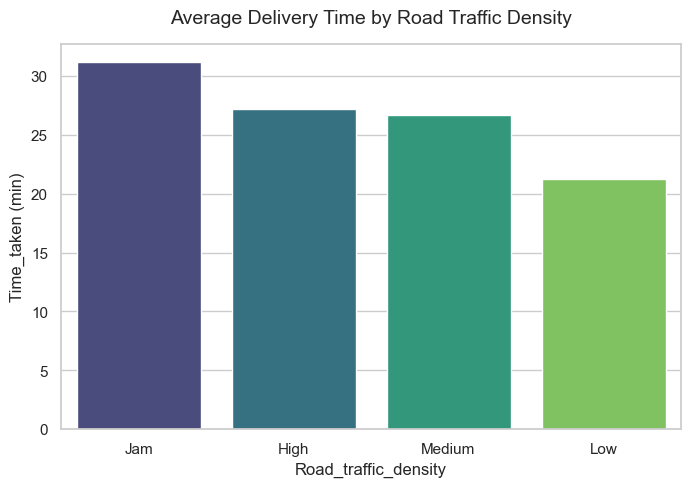

In [39]:
# Graph 1: Average Delivery Time by Road Traffic Density
fig, ax = plt.subplots(figsize=(8, 5))
traffic_time = df.groupby('Road_traffic_density')['Time_taken (min)'].mean().sort_values(ascending=False).reset_index()
# FIXED LINE: Added hue mapping alongside palette and legend
sns.barplot(
    data=traffic_time, 
    x='Road_traffic_density', 
    y='Time_taken (min)', 
    hue='Road_traffic_density',  # <--- MUST ADD THIS LINE
    palette='viridis', 
    legend=False, 
    ax=ax
)
ax.set_title('Average Delivery Time by Road Traffic Density', fontsize=14, pad=15)

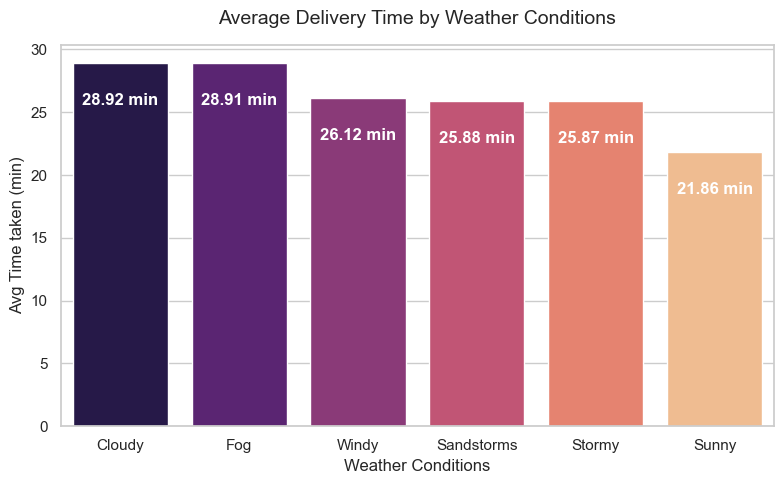

In [53]:
# Graph 2: Average Delivery Time by Weather Conditions
fig, ax = plt.subplots(figsize=(8, 5))
weather_time = df.groupby('Weather_conditions')['Time_taken (min)'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=weather_time, x='Weather_conditions', y='Time_taken (min)',hue='Weather_conditions', palette='magma', ax=ax)
ax.set_title('Average Delivery Time by Weather Conditions', fontsize=14, pad=15)
ax.set_xlabel('Weather Conditions', fontsize=12)
ax.set_ylabel('Avg Time taken (min)', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} min", (p.get_x() + p.get_width() / 2., p.get_height() - 3),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig('graph2_weather_conditions.png')
plt.show()

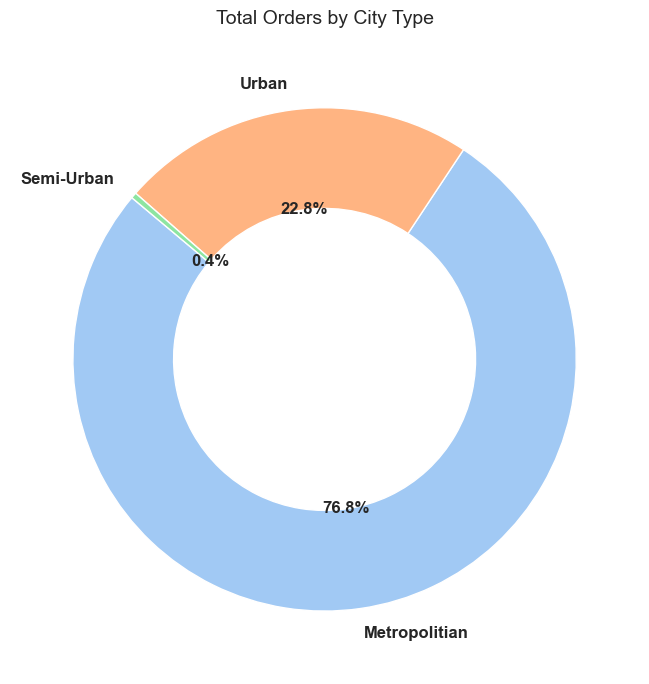

In [54]:
# Graph 3: Total Orders by City Type
fig, ax = plt.subplots(figsize=(7, 7))
city_counts = df['City'].value_counts()
ax.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel')[0:3],
       textprops={'fontsize': 12, 'weight': 'bold'}, wedgeprops=dict(width=0.4, edgecolor='w'))
ax.set_title('Total Orders by City Type', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('graph3_city_orders.png')
plt.show()

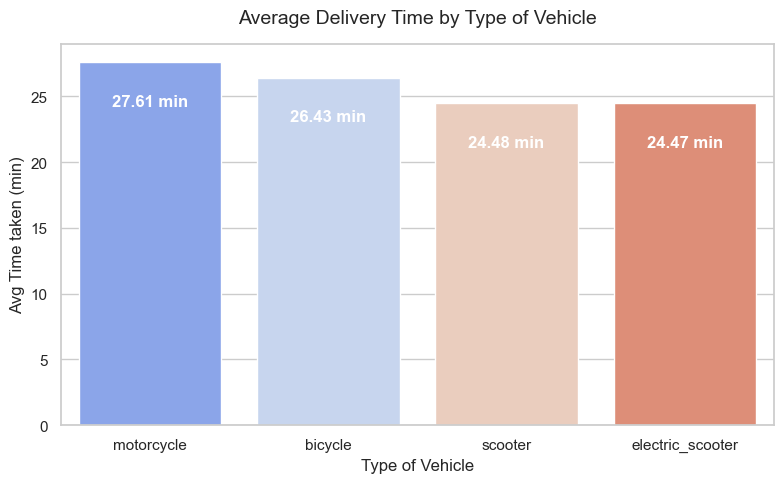

In [52]:
# Graph 4: Average Delivery Time by Type of Vehicle
fig, ax = plt.subplots(figsize=(8, 5))
vehicle_time = df.groupby('Type_of_vehicle')['Time_taken (min)'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=vehicle_time, x='Type_of_vehicle', y='Time_taken (min)', hue= 'Type_of_vehicle',palette='coolwarm', ax=ax)
ax.set_title('Average Delivery Time by Type of Vehicle', fontsize=14, pad=15)
ax.set_xlabel('Type of Vehicle', fontsize=12)
ax.set_ylabel('Avg Time taken (min)', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} min", (p.get_x() + p.get_width() / 2., p.get_height() - 3),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig('graph4_vehicle_time.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_14632\2535594573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order_type_counts, x='Type_of_order', y='Count', palette='Blues_r', ax=ax)


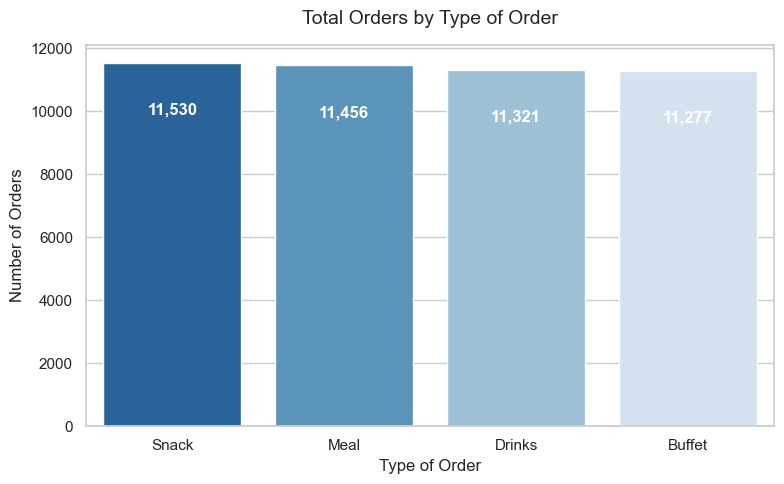

In [55]:
# Graph 5: Total Orders by Type of Order
fig, ax = plt.subplots(figsize=(8, 5))
order_type_counts = df['Type_of_order'].value_counts().sort_values(ascending=False).reset_index()
order_type_counts.columns = ['Type_of_order', 'Count']
sns.barplot(data=order_type_counts, x='Type_of_order', y='Count', hue='',palette='Blues_r', ax=ax)
ax.set_title('Total Orders by Type of Order', fontsize=14, pad=15)
ax.set_xlabel('Type of Order', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height() - 1500),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig('graph5_order_type.png')
plt.show()

In [ ]:


# Graph 6: Distribution of Delivery Partner Ratings
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Delivery_person_Ratings'].dropna(), bins=20, kde=True, color='purple', ax=ax)
ax.set_title('Distribution of Delivery Partner Ratings', fontsize=14, pad=15)
ax.set_xlabel('Ratings', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('graph6_ratings_distribution.png')
plt.close(fig)

In [ ]:
# Graph 7: Trend of Daily Orders
fig, ax = plt.subplots(figsize=(10, 5))
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')
daily_orders = df.groupby('Order_Date').size().reset_index(name='Order_Count')
sns.lineplot(data=daily_orders, x='Order_Date', y='Order_Count', marker='o', color='crimson', linewidth=2, ax=ax)
ax.set_title('Trend of Daily Orders', fontsize=14, pad=15)
ax.set_xlabel('Order Date', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graph7_daily_orders_trend.png')
plt.close(fig)
print("All graphs generated successfully!")